# **1. Исследование данных**

**Контекст задачи**: 

- Необходимо построить модель бинарной классификации для определения, является ли cookie_id ботом (1) или человеком (0).

**Ключевое ограничение на данные:** 

- Признаки строятся только из событий внутри окна `[window_start_ts, window_end_ts]`.

#### **Данные**

**1. train.csv / test.csv**:

* `cookie id` - идентификатор куки;

* `cookie_created_at` - время первого появления куки, которое может быть раньше начала окна наблюдения;

* `window_start_ts`, `window_end_ts` - начало и конец окна наблюдения.

**2. events.csv**

* `cookie_id` — идентификатор куки;

* `event_ts` - время события;

* `eid`, `event_name` - код и название типа события;

* `platform` - платформа;

* `user_agent` - строка User-Agent;

* `item_id`, `item_category`, `item_location`, `seller_type` - идентификатор объявления его категория локация и тип

* `search_query`, `search_page` - поисковый запрос и номер страницы выдачи;

* `pointer_x`, `pointer_y` - координаты курсора в момент события.

## **1.1. Загрузка данных и анализ структуры**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
DATA_DIR = Path("../data")

Загружаем `train.csv`, `test.csv`, `events.csv`:

In [4]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

In [5]:
display(train.head())
print(f"\nТипы данных:\n{train.dtypes}")
print(f"\nПропуски:\n{train.isnull().sum()}")

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0



Типы данных:
cookie_id              str
cookie_created_at      str
window_start_ts        str
window_end_ts          str
target               int64
dtype: object

Пропуски:
cookie_id            0
cookie_created_at    0
window_start_ts      0
window_end_ts        0
target               0
dtype: int64


In [6]:
display(test.head())
print(f"\nПропуски:\n{test.isnull().sum()}")

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21



Пропуски:
cookie_id            0
cookie_created_at    0
window_start_ts      0
window_end_ts        0
dtype: int64


In [7]:
display(events.head())
print(f"\nТипы данных:\n{events.dtypes}")
print(f"\nПропуски:\n{events.isnull().sum()[events.isnull().sum() != 0]}")

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN



Типы данных:
cookie_id            str
event_ts             str
eid                int64
event_name           str
platform             str
user_agent           str
item_id          float64
item_category        str
item_location        str
seller_type          str
search_query         str
search_page      float64
pointer_x        float64
pointer_y        float64
dtype: object

Пропуски:
item_id          114597
item_category     32920
item_location     23793
seller_type      133853
search_query     228503
search_page      228503
pointer_x        220365
pointer_y        220365
dtype: int64


Приведем даты к верному формату:

In [8]:
for col in ["cookie_created_at", "window_start_ts", "window_end_ts"]:
    train[col] = pd.to_datetime(train[col])
    test[col] = pd.to_datetime(test[col])

events["event_ts"] = pd.to_datetime(events["event_ts"])

## **1.2. Анализ данных**

Первое, что необходимо проверить это насколько сбалансированы классы, поскольку это влияет на дальнейшее решение задачи:

Баланс классов:
  Класс 0 (человек): 10192 (91.89%)
  Класс 1 (бот): 899 (8.11%)


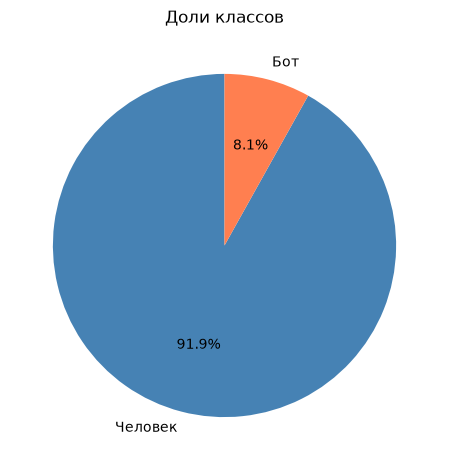

In [9]:
target_counts = train['target'].value_counts()
target_ratio = train['target'].mean()

print(f"Баланс классов:")
print(f"  Класс 0 (человек): {target_counts[0]} ({1-target_ratio:.2%})")
print(f"  Класс 1 (бот): {target_counts[1]} ({target_ratio:.2%})")

plt.pie([1-target_ratio, target_ratio], 
            labels=['Человек', 'Бот'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'],
            startangle=90)
plt.title('Доли классов')

plt.tight_layout()
plt.show()

Заметим сильный дисбаланс классов в пользу класса 0 (человек). Будем иметь это ввиду при обучении.

Как видим из вывода, все окна одинаковые и составляют целые 24 часа.

Следующим шагом, будем создание датафрейма, которой будет представлять собой объединение двух таблиц `train.csv` и `events.csv` по ключу `cookie_id`, а также с фильтрацией по окну, чтобы недопустить утечку данных.

In [11]:
# Объединяем события с окнами по cookie_id
train_windows = train[['cookie_id', 'window_start_ts', 'window_end_ts', 'target']].copy()
events_merged = events.merge(train_windows, on='cookie_id', how='inner')

# Фильтруем по времени
mask = (
    (events_merged['event_ts'] >= events_merged['window_start_ts']) &
    (events_merged['event_ts'] <= events_merged['window_end_ts'])
)
events_filtered = events_merged[mask].copy()

In [12]:
print(f"Количество событий до фильтрации: {len(events)}")
print(f"Количество событий после фильтрации: {len(events_filtered)}")
print(f"Уникальных cookie в отфильтрованных событиях: {events_filtered['cookie_id'].nunique()} из {len(train)}")

Количество событий до фильтрации: 328905
Количество событий после фильтрации: 198504
Уникальных cookie в отфильтрованных событиях: 11091 из 11091


### **1.2.1. Анализ количества событий**

Теперь имеем единую таблицу с `cookie_id` и связанные с ним событие, которые происходили строго в рамках окна. Проведем анализ количества событий на одну `cookie_id`. 

In [13]:
# Считаем количество событий для каждой куки (size() - считает количество строк для каждой куки)
event_counts = events_filtered.groupby('cookie_id').size().reset_index(name='event_count')
df_analysis = train.merge(event_counts, on='cookie_id', how='left')

print("Статистика для людей:\n")
print(df_analysis[df_analysis['target'] == 0]['event_count'].describe())

print("\nСтатистика для ботов:\n")
print(df_analysis[df_analysis['target'] == 1]['event_count'].describe())

Статистика для людей:

count    10192.000000
mean        16.875392
std         16.173568
min          1.000000
25%          6.000000
50%         12.000000
75%         22.000000
max        140.000000
Name: event_count, dtype: float64

Статистика для ботов:

count    899.000000
mean      29.488320
std       27.512391
min        1.000000
25%       11.000000
50%       20.000000
75%       38.000000
max      169.000000
Name: event_count, dtype: float64


Исходя из данного анализа, можешь сформировать гипотезу о том, что в среднем боты делают большее количество событий. Построим гистограмму распределения событий для визуального анализа:

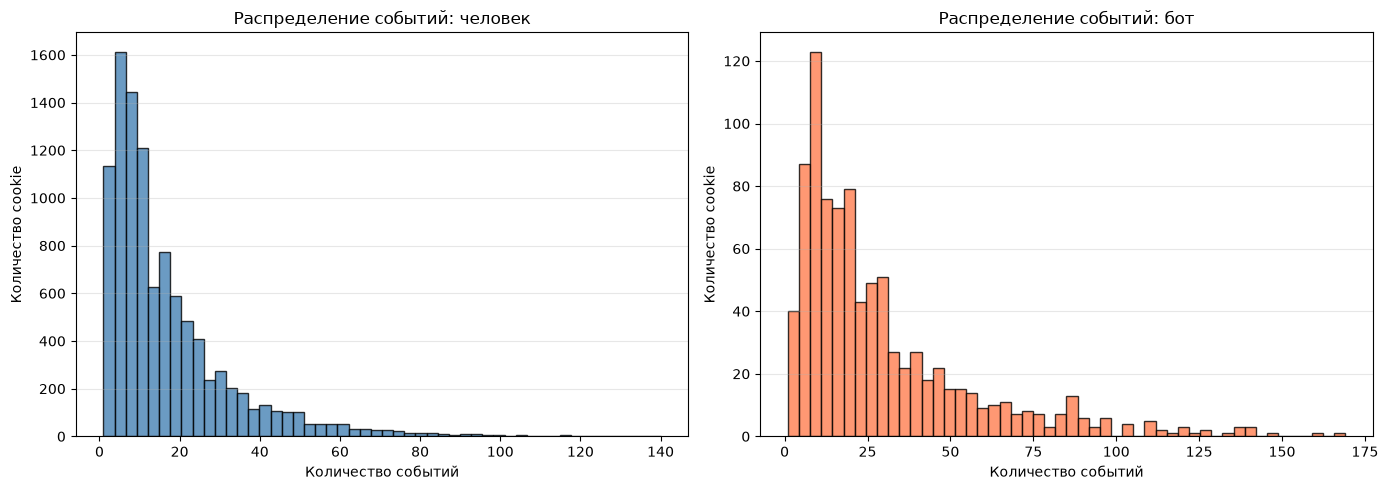

In [14]:
humans = df_analysis[df_analysis['target'] == 0]['event_count']
bots = df_analysis[df_analysis['target'] == 1]['event_count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(humans, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Распределение событий: человек')
axes[0].set_xlabel('Количество событий')
axes[0].set_ylabel('Количество cookie')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(bots, bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Распределение событий: бот')
axes[1].set_xlabel('Количество событий')
axes[1].set_ylabel('Количество cookie')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Расределения имеют схожий характер, поэтому опираться лишь на количество событий для классификации недостаточно.

### **1.2.2. Анализ типов событий**

Посмотрим какие именно события совершают люди и боты. Возможно боты чаще делают определенные типы событий.

In [33]:
# Считаем количество каждого типа событий для каждого класса
event_type_by_class = events_filtered.groupby(['target', 'event_name']).size().unstack(fill_value=0)

# Нормализуем
event_type_by_class_pct = event_type_by_class.div(event_type_by_class.sum(axis=1), axis=0) * 100

print("Доля каждого типа событий:")
display(event_type_by_class_pct.round(2))

Доля каждого типа событий:


event_name,captcha_shown,contact_chat_open,contact_message_sent,contact_phone_show,favorite_add,item_view,login,photo_swipe,search_results_view,seller_page_view
target,,,,,,,,,,
0,0.00,1.98,1.03,3.70,6.58,36.51,2.15,12.27,30.47,5.31
1,0.01,1.42,0.79,2.58,2.72,43.64,0.78,7.02,35.15,5.90


Визуализируем события с максимальной разницей между классами:

Топ-10 событий с максимальной разницей в долях между классами:
event_name
item_view               7.129858
photo_swipe             5.253975
search_results_view     4.675263
favorite_add            3.864804
login                   1.368075
contact_phone_show      1.116198
seller_page_view        0.588726
contact_chat_open       0.561969
contact_message_sent    0.236370
captcha_shown           0.007544
dtype: float64


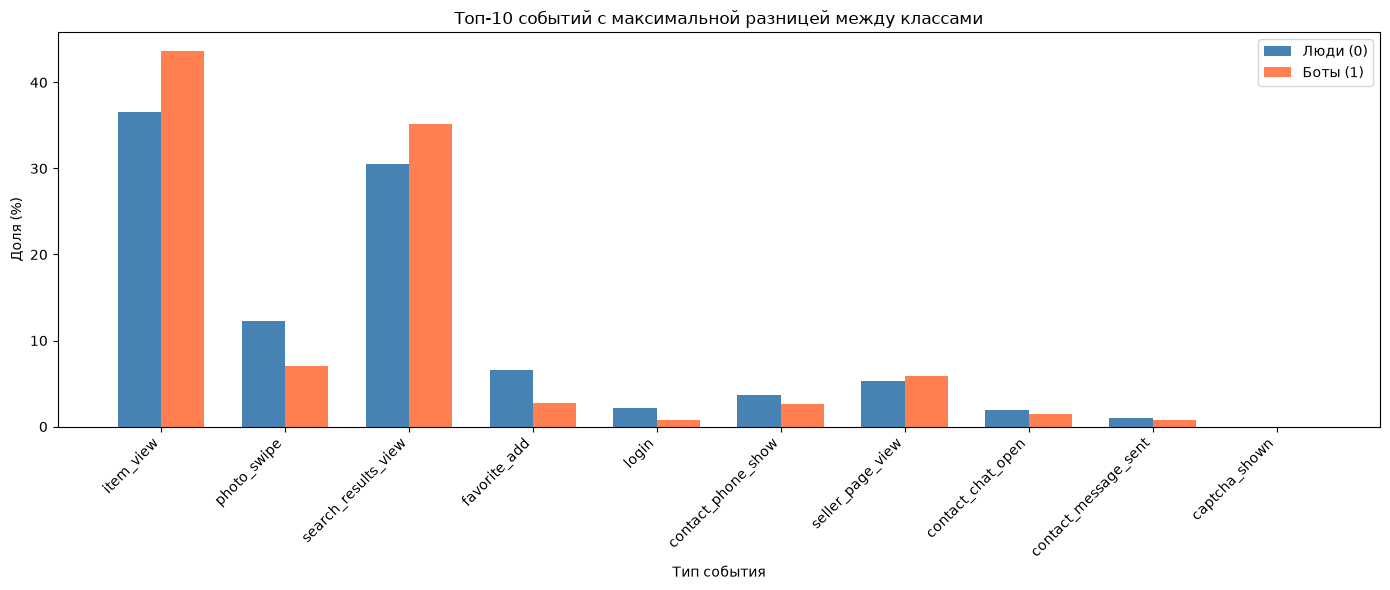

In [35]:
difference = event_type_by_class_pct.loc[1] - event_type_by_class_pct.loc[0]

# Сортируем
difference_sorted = difference.abs().sort_values(ascending=False)

print("Топ-10 событий с максимальной разницей в долях между классами:")
print(difference_sorted.head(10))

top_discriminative = difference_sorted.head(10).index

plt.figure(figsize=(14, 6))
x = np.arange(len(top_discriminative))
width = 0.35

plt.bar(x - width/2, event_type_by_class_pct.loc[0, top_discriminative], width, label='Люди (0)', color='steelblue')
plt.bar(x + width/2, event_type_by_class_pct.loc[1, top_discriminative], width, label='Боты (1)', color='coral')

plt.xlabel('Тип события')
plt.ylabel('Доля (%)')
plt.title('Топ-10 событий с максимальной разницей между классами')
plt.xticks(x, top_discriminative, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Исходя из результатов:

**1. Боты чаще совершают:**

* `item_view` (+7.13%) - боты массово просматривают объявления

* `search_results_view` (+4.68%) - боты часто смотрят результаты поиска

**2. Люди чаще совершают:**
 
* `photo_swipe` (-5.25%) - люди листают фото товаров (интерес к конкретному объявлению)

* `favorite_add` (-3.86%) - люди добавляют в избранное (планируют покупку)

* `login` (-1.37%) - люди логинятся в аккаунт

* `contact_phone_show` (-1.12%) - люди смотрят контакты продавцов

Можем сделать вывод о том, что боты совершают более пассивный скроллинг, чем люди, которые активнее добавляют товар в избранное, логинятся и смотрят контакты.

### **1.2.3. Анализ платформы**

Рассмотрим более подробно с каких платформ выполняют действия боты и люди. Но сначала определим какие значения они могут принимать:

In [43]:
print("Уникальные значения:")
platform_counts_all = events_filtered['platform'].value_counts()
print(platform_counts_all)
print(f"\nВсего значений: {events_filtered['platform'].nunique()}")

Уникальные значения:
platform
desktop    27864
Web        27481
WEB        27441
web        27261
ANDROID    26216
Android    25904
android    25897
IOS         2636
iOS         2626
iphone      2602
ios         2576
Name: count, dtype: int64

Всего значений: 11


То есть заметим, что реальных категорий всего три: 

* `web`

* `ios`

* `android`

Остальные категории это либо разница в регистре, либо слово синоним. Приведем все к единому формату с тремя категориями.

In [44]:
# Приводим все значения к нижнему регистру для унификации
events_filtered['platform_clean'] = events_filtered['platform'].str.lower()

# Заменяем 'desktop' на 'web' (синонимы)
events_filtered['platform_clean'] = events_filtered['platform_clean'].replace('desktop', 'web')

# Заменяем 'iphone' на 'ios' (одна платформа)
events_filtered['platform_clean'] = events_filtered['platform_clean'].replace('iphone', 'ios')

print("Уникальные значения после предобработки:")
print(events_filtered['platform_clean'].value_counts())

Уникальные значения после предобработки:
platform_clean
web        110047
android     78017
ios         10440
Name: count, dtype: int64


Отлично, теперь можем перейти к анализу распределения платформ по классам и сформулировать гипотезу:

In [55]:
platform_by_target = events_filtered.groupby(['target', 'platform_clean']).size().unstack(fill_value=0)
platform_pct = platform_by_target.div(platform_by_target.sum(axis=1), axis=0) * 100

print("Распределение платформ по классам (%):")
display(platform_pct.round(2))

Распределение платформ по классам (%):


platform_clean,android,ios,web
target,,,
0,41.75,5.75,52.50
1,23.42,2.09,74.49


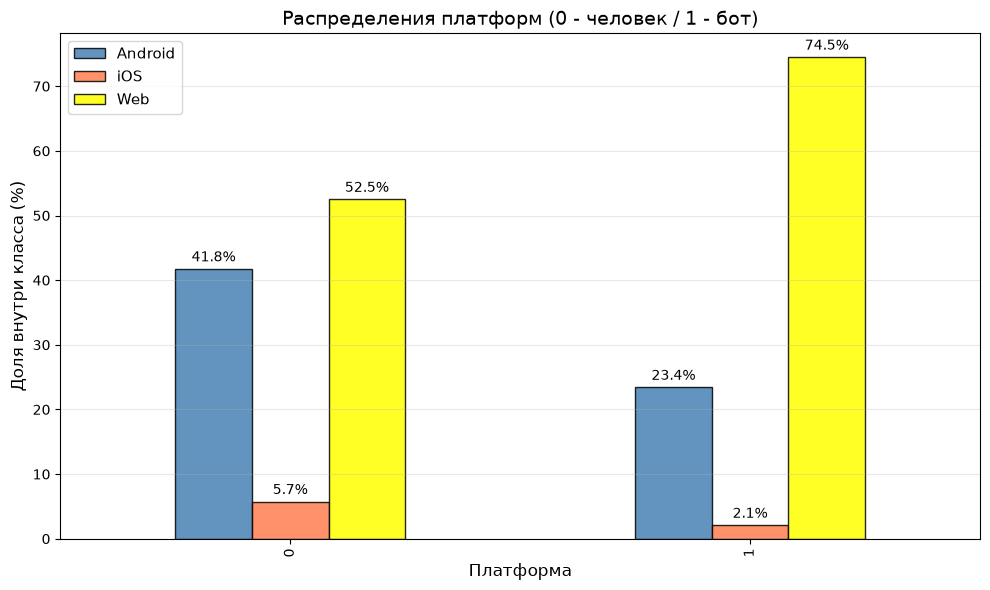

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

platform_pct.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'yellow'], alpha=0.85, edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10, padding=3)

ax.set_xlabel('Платформа', fontsize=12)
ax.set_ylabel('Доля внутри класса (%)', fontsize=12)
ax.set_title('Распределения платформ (0 - человек / 1 - бот)', fontsize=14)
ax.legend(['Android', 'iOS', 'Web'], fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Боты и люди имеют разные предпочтения по платформе:

- Боты доминирует на `Web` (74.5%)

- Люди равномерно распределены между мобильными и веб платформами: (47.5% и 52.5%)

Гипотеза для признака:

- `platform_web_ratio` - доля событий с Web

- `platform_mobile_ratio` - доля событий с Android/iOS

- или просто категориальный признак `platform`

### **1.2.4. Анализ типа продавца**

Аналогично платформе, посмотрим на уникальные значение, а также на количество пропусков:

In [62]:
print("Уникальные значения:")
print(events_filtered['seller_type'].value_counts())
print(f"\nКоличество пропусков: {events_filtered['seller_type'].isnull().sum()}")

Уникальные значения:
seller_type
private    69756
pro        51069
Name: count, dtype: int64

Количество пропусков: 77679


Заметим большое количество пропусков (77679). Для простоты сделаем отдельную категорию для пропуска `unknown` - возможно появление пропуска будет полезно при классификации.

In [63]:
events_filtered['seller_type_clean'] = events_filtered['seller_type'].fillna('unknown')

# Считаем количество событий по типам продавцов для каждого класса
seller_counts = events_filtered.groupby(['target', 'seller_type_clean']).size().unstack(fill_value=0)
seller_pct = seller_counts.div(seller_counts.sum(axis=1), axis=0) * 100

print("Распределение типов продавцов внутри каждого класса (%):")
display(seller_pct.round(2))

Распределение типов продавцов внутри каждого класса (%):


seller_type_clean,private,pro,unknown
target,,,
0,35.66,25.58,38.75
1,31.75,26.65,41.60


Распределения очень схожи между классами, поэтому однозначной гипотезы сделать не можем. Данный признак, скорее всего, будет слабо влиять на классификацию, однако отбрасывать его не будем.

### **1.2.5. Анализ user_agent**

Перейдем к более интересной составляющей событий, а именно - `user_agent`. 

`user_agent` - строка, которую браузер (или другой клиент) отправляет веб-серверу при каждом запросе. 

Она содержит информацию о:

- Браузере и его версии (Chrome, Firefox, Safari, etc.)

- Операционной системе (Windows, macOS, Android, iOS, etc.)

- Устройстве (desktop, mobile, tablet)

Иногда о дополнительных компонентах (рендер-движок, плагины)

In [67]:
print("Уникальные значения:")
print(events_filtered['user_agent'].value_counts())
print(f"\nВсего значений: {events_filtered['user_agent'].nunique()}")

Уникальные значения:
user_agent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Safari/537.36     2330
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.11.0.0 Safari/537.36    2254
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36                  2253
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 YaBrowser/23.9.0.0 Safari/537.36     2183
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 YaBrowser/23.3.0.0 Safari/537.36     2181
                                                                                                                                       ... 
python-urllib3/2.0.7                                                                                                            

Первое, на что стоит посмотреть - длина `user_agent`.

Статистика длины user_agent:
           count       mean        std   min   25%    50%    75%    max
target                                                                 
0       171994.0  99.241410  30.922856  10.0  80.0  117.0  118.0  135.0
1        26510.0  93.266918  33.436573  10.0  80.0  109.0  117.0  135.0


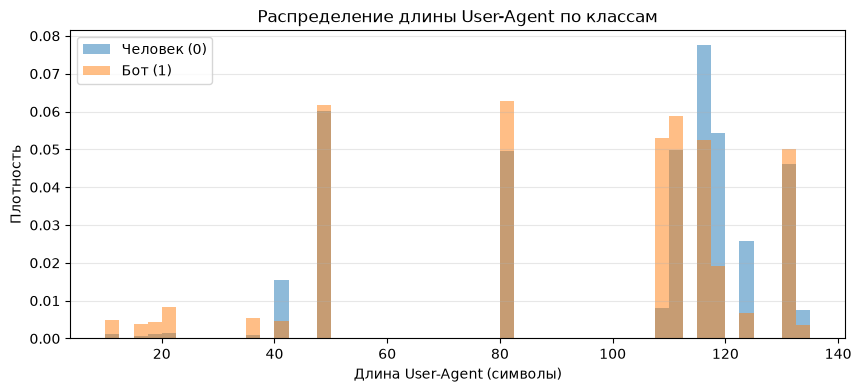

In [71]:
# Вычисляем длину строки user_agent для каждого события
events_filtered['ua_length'] = events_filtered['user_agent'].str.len()

# Сравниваем среднюю длину user_agent между классами
print("Статистика длины user_agent:")
print(events_filtered.groupby('target')['ua_length'].describe())

plt.figure(figsize=(10, 4))
plt.hist(events_filtered[events_filtered['target'] == 0]['ua_length'], 
         bins=50, alpha=0.5, label='Человек (0)', density=True)
plt.hist(events_filtered[events_filtered['target'] == 1]['ua_length'], 
         bins=50, alpha=0.5, label='Бот (1)', density=True)
plt.xlabel('Длина User-Agent (символы)')
plt.ylabel('Плотность')
plt.title('Распределение длины User-Agent по классам')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Также выведем наиболее популярные user_agent в данных для людей и для ботов:

In [78]:
print("Топ-5 user_agent для людей (target=0):")
human_ua = events_filtered[events_filtered['target'] == 0]['user_agent'].value_counts().head(5)
for i, (ua, count) in enumerate(human_ua.items(), 1):
    print(f"  {i}. ({count} событий) {ua}")

print("\nТоп-5 user_agent для ботов (target=1):")
bot_ua = events_filtered[events_filtered['target'] == 1]['user_agent'].value_counts().head(5)
for i, (ua, count) in enumerate(bot_ua.items(), 1):
    print(f"  {i}. ({count} событий) {ua}")

Топ-5 user_agent для людей (target=0):
  1. (2154 событий) Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 YaBrowser/23.0.0.0 Safari/537.36
  2. (1913 событий) Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 YaBrowser/23.1.0.0 Safari/537.36
  3. (1901 событий) Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36
  4. (1885 событий) Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36
  5. (1875 событий) Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36

Топ-5 user_agent для ботов (target=1):
  1. (1217 событий) Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/118.0.0.0 Safari/537.36
  2. (1040 событий) Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gec

**Выводы**:

1. Длина `user_agent`:

- Люди: median = 117 символов

- Боты: median = 109 символов

- Разница небольшая, но есть

2. Топ-3 самых частых user_agent у ботов - это `HeadlessChrome` на `Linux`: можем попробовать сделать отдельный бинарный признак `has_headless`.

3. ОС:

- Боты: Linux (X11; Linux x86_64) — серверная среда

- Люди: Windows NT 10.0, Macintosh — десктопные ОС


На основе этого анализа можно создать следующие признаки:

- `has_headless` - содержит ли UA слово "Headless"

- `is_linux` - используется ли Linux

- `is_windows` - используется ли Windows

- `is_mac` - используется ли Mac

- `ua_length` - длина строки UA

### **1.2.6. Анализ временных интервалов между событиями**

Есть смысл посмотреть на разницу между ближайшими событиями. Поскольку бот может быстрее выполнять действия, а следовательно, интервал будет короче. 

In [83]:
# Сортируем события по cookie_id и времени
events_sorted = events_filtered.sort_values(['cookie_id', 'event_ts'])

# Считаем разницу между текущим и предыдущим событием для каждой куки
events_sorted['time_diff_sec'] = events_sorted.groupby('cookie_id')['event_ts'].diff().dt.total_seconds()

# Убираем первые события (у них NaN в time_diff)
events_with_diff = events_sorted.dropna(subset=['time_diff_sec']).copy()

print("Статистика интервалов между событиями (сек)")
interval_stats = events_with_diff.groupby('target')['time_diff_sec'].describe()
print(interval_stats)

Статистика интервалов между событиями (сек)
           count        mean          std  min   25%   50%    75%      max
target                                                                    
0       161802.0  744.802197  2047.418533  0.0  19.0  46.0  117.0  81335.0
1        25611.0  427.569794  1526.100843  0.0   7.0  14.0   35.0  56717.0


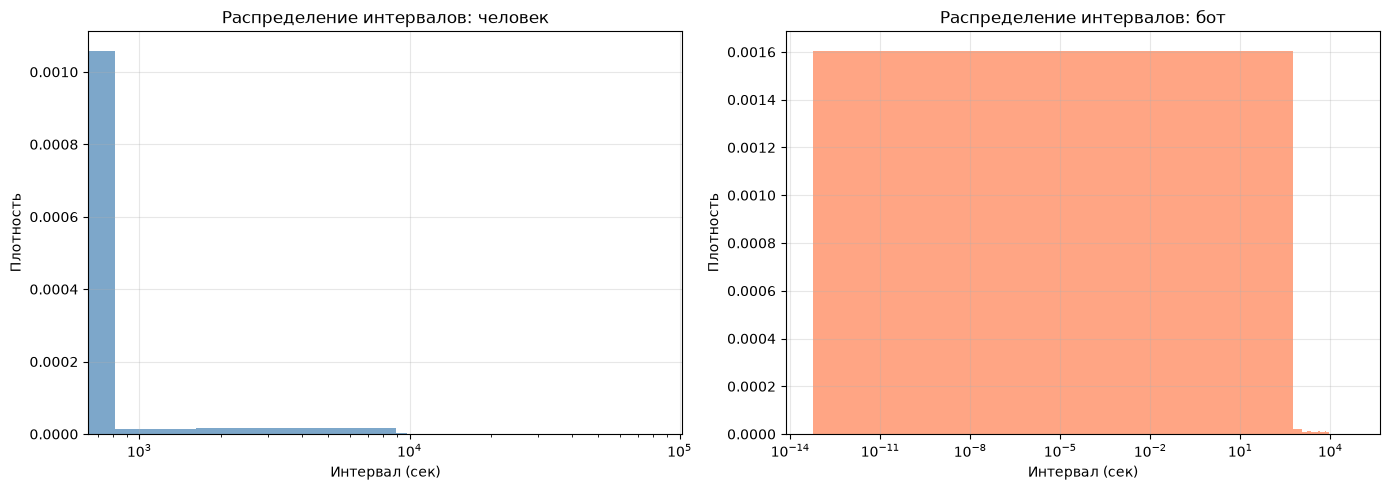

In [86]:
# Визуализация: распределение интервалов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма для людей
axes[0].hist(
    events_with_diff[events_with_diff['target'] == 0]['time_diff_sec'],
    bins=100, color='steelblue', alpha=0.7, density=True
)
axes[0].set_title('Распределение интервалов: человек')
axes[0].set_xlabel('Интервал (сек)')
axes[0].set_ylabel('Плотность')
axes[0].set_xscale('log')
axes[0].grid(alpha=0.3)

# Гистограмма для ботов
axes[1].hist(
    events_with_diff[events_with_diff['target'] == 1]['time_diff_sec'],
    bins=100, color='coral', alpha=0.7, density=True
)
axes[1].set_title('Распределение интервалов: бот')
axes[1].set_xlabel('Интервал (сек)')
axes[1].set_ylabel('Плотность')
axes[1].set_xscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Боты действительно совершают действия в разы чаще (медианный интервал 14 секунд у человека и 46 секунд у бота). 

Гипотеза для признаков:

- `median_interval_sec` - медианный интервал

- `ratio_instant_events` - доля событий с интервалом < 1 сек

- `events_per_minute` - скорость действий

### **1.2.7. Анализ разнообразия контента и географии**

Аналогично можем сделать предположение о том, что человек обычно смотрит меньше объявлений и категорий, чем бот. Проверим это:

In [90]:
# Считаем количество уникальных значений для каждой куки
diversity_stats = events_filtered.groupby('cookie_id').agg(
    unique_items=('item_id', 'nunique'),
    unique_categories=('item_category', 'nunique'),
    unique_locations=('item_location', 'nunique'),
    total_events=('event_name', 'size') # для нормализации
).reset_index()

# Объединяем с таргетом
diversity_stats = diversity_stats.merge(train[['cookie_id', 'target']], on='cookie_id')

print("Среднее количество уникальных значений на cookie_id:")
print(diversity_stats.groupby('target')[['unique_items', 'unique_categories', 'unique_locations']].mean().round(2))

Среднее количество уникальных значений на cookie_id:
        unique_items  unique_categories  unique_locations
target                                                   
0               8.92               2.28              5.88
1              13.78               1.79              9.79


Заметим интересный момент, боты парсят больше товаров, но при этом меньше категорий. Можем сделать предположение, что бот фокусируется на 1-2 категориях и сканирует внутри них десятки товаров. Человек же наоборот подходит более разнообразно.

На основе этого создадим:

- `unique_items` — количество уникальных товаров

- `unique_categories` — количество категорий

- `unique_locations` — количество городов

- `items_per_category` = unique_items / unique_categories

### **1.2.8. Анализ поискового поведения**

Люди вводят осмысленные запросы и редко уходят дальше 3-5 страницы выдачи. Боты могут иметь пустые запросы при скроллинге выдачи или уходить на 50+ страницы.

In [94]:
events_filtered['search_query'].nunique

<bound method IndexOpsMixin.nunique of 0                      NaN
1            пылесос dyson
2           костюм мужской
4                      NaN
5                      NaN
                ...       
239210                 NaN
239211                 NaN
239212                 NaN
239213    работа водителем
239214                лыжи
Name: search_query, Length: 198504, dtype: str>

In [96]:
print(f"Количество пропусков: {events_filtered['search_query'].isnull().sum()}")

Количество пропусков: 136773


In [99]:
# Доля событий, где был указан search_query
search_ratio = events_filtered.groupby('cookie_id').apply(
    lambda x: (x['search_query'].notna().sum() / len(x))
).reset_index(name='search_query_ratio')
search_ratio = search_ratio.merge(train[['cookie_id', 'target']], on='cookie_id')

print("Средняя доля событий с поисковым запросом:")
print(search_ratio.groupby('target')['search_query_ratio'].mean().round(3))

# Максимальная глубина страницы выдачи (берем максимальную страницу для куки, а дальше усредним для каждого класса)
max_page = events_filtered[events_filtered['search_page'].notna()].groupby('cookie_id')['search_page'].max().reset_index(name='max_search_page')
max_page = max_page.merge(train[['cookie_id', 'target']], on='cookie_id')

print("\nСредняя максимальная страница выдачи:")
print(max_page.groupby('target')['max_search_page'].mean().round(2))

Средняя доля событий с поисковым запросом:
target
0    0.308
1    0.331
Name: search_query_ratio, dtype: float64

Средняя максимальная страница выдачи:
target
0    4.42
1    9.30
Name: max_search_page, dtype: float64


**Выводы:**

- Доля событий с поисковым запросом: разница минимальна, сам по себе факт поиска не является маркером бота.

- Максимальная страница выдачи: разница почти в два раза, есть смысл сгенерировать данный признак.

### **1.2.8. Анализ координат курсора**

У людей курсор двигается часто (особенно на десктопе). У ботов координат курсора может не быть вообще, либо они двигаются по идеальной прямой (что сложно увидеть на агрегации, но отсутствие данных — уже мощный сигнал).

In [108]:
pointer_data = events_filtered.copy()
pointer_data['has_pointer'] = pointer_data['pointer_x'].notna() & pointer_data['pointer_y'].notna()

pointer_ratio = pointer_data.groupby('cookie_id').agg(
    pointer_ratio=('has_pointer', 'mean'),
    total_events=('has_pointer', 'count'),
    pointer_events=('has_pointer', 'sum')
).reset_index()

pointer_ratio = pointer_ratio.merge(train[['cookie_id', 'target']], on='cookie_id')

print("Средняя доля событий с координатами курсора:")
print(f"  Люди (0): {pointer_ratio[pointer_ratio['target']==0]['pointer_ratio'].mean():.1%}")
print(f"  Боты (1): {pointer_ratio[pointer_ratio['target']==1]['pointer_ratio'].mean():.1%}")


Средняя доля событий с координатами курсора:
  Люди (0): 35.4%
  Боты (1): 26.5%


### **1.2.9. Анализ временных паттернов**

Активность человека резко падает с 00:00 до 06:00. Боты работают 24/7, поэтому их распределение по часам суток будет более равномерным или иметь пики в ночное время.

Распределение активности по часам суток (%):


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
target,,,,,,,,,,,,,,,,,,,,,
0,1.0,1.4,2.1,2.5,2.8,3.2,2.9,3.2,3.3,3.6,...,5.1,5.2,5.0,5.2,5.5,6.2,5.9,6.0,6.2,5.5
1,2.5,3.1,4.3,5.6,4.0,4.8,3.6,4.0,4.6,4.0,...,4.5,3.8,3.4,4.1,4.2,4.1,5.9,4.5,4.5,4.8


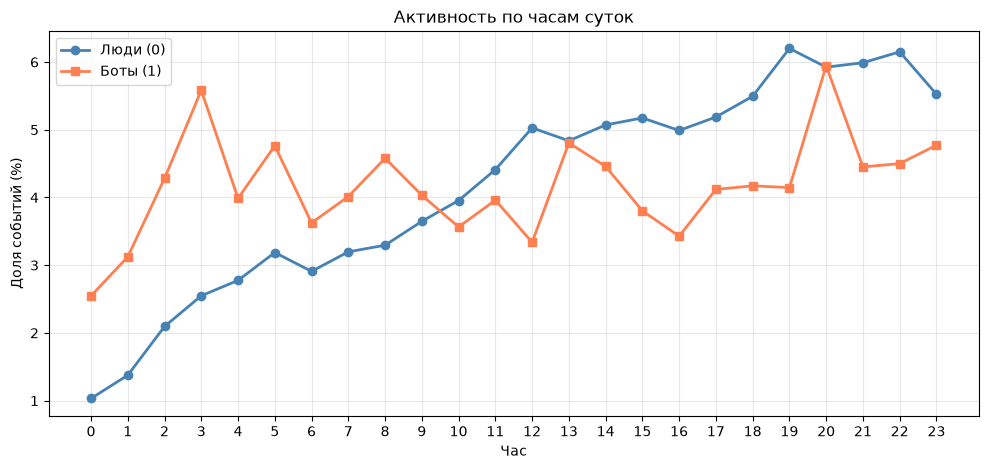

In [101]:
# Извлекаем час из event_ts
events_filtered['hour'] = events_filtered['event_ts'].dt.hour

# Считаем распределение событий по часам для каждого класса
hourly_dist = events_filtered.groupby(['target', 'hour']).size().unstack(fill_value=0)
hourly_dist_pct = hourly_dist.div(hourly_dist.sum(axis=1), axis=0) * 100

print("Распределение активности по часам суток (%):")
display(hourly_dist_pct.round(1))

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(hourly_dist_pct.loc[0].index, hourly_dist_pct.loc[0].values, marker='o', label='Люди (0)', color='steelblue', linewidth=2)
plt.plot(hourly_dist_pct.loc[1].index, hourly_dist_pct.loc[1].values, marker='s', label='Боты (1)', color='coral', linewidth=2)

plt.xlabel('Час')
plt.ylabel('Доля событий (%)')
plt.title('Активность по часам суток')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Гипотеза подтвердилась, активность ботов ночью обычно больше, чем у людей. Обязательно будем использовать эту информацию при генерирование фичей.